In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from funciones import derivadas, a_cartesiano

In [13]:
# Implementacion de Euler explicito en estilo manual
# No usamos vectores numpy: la idea es que el loop sea legible paso a paso
def euler_explicito(estado_inicial, alpha, delta, theta0, theta_fin, h):
    num_pasos = int((theta_fin - theta0) / h)

    dt = h
    ti = theta0
    lt = [ti + dt*i for i in range(num_pasos + 1)]

    mu = [0.0] * (num_pasos + 1)
    y  = [0.0] * (num_pasos + 1)
    mu[0] = estado_inicial[0]
    y[0]  = estado_inicial[1]

    for i in range(num_pasos):
        # Derivadas en el punto actual (Euler hacia adelante)
        dmu = y[i]
        dy  = -mu[i] + 1.0/alpha + delta * mu[i]**2
        mu[i+1] = mu[i] + h * dmu
        y[i+1]  = y[i]  + h * dy

    return lt, mu, y

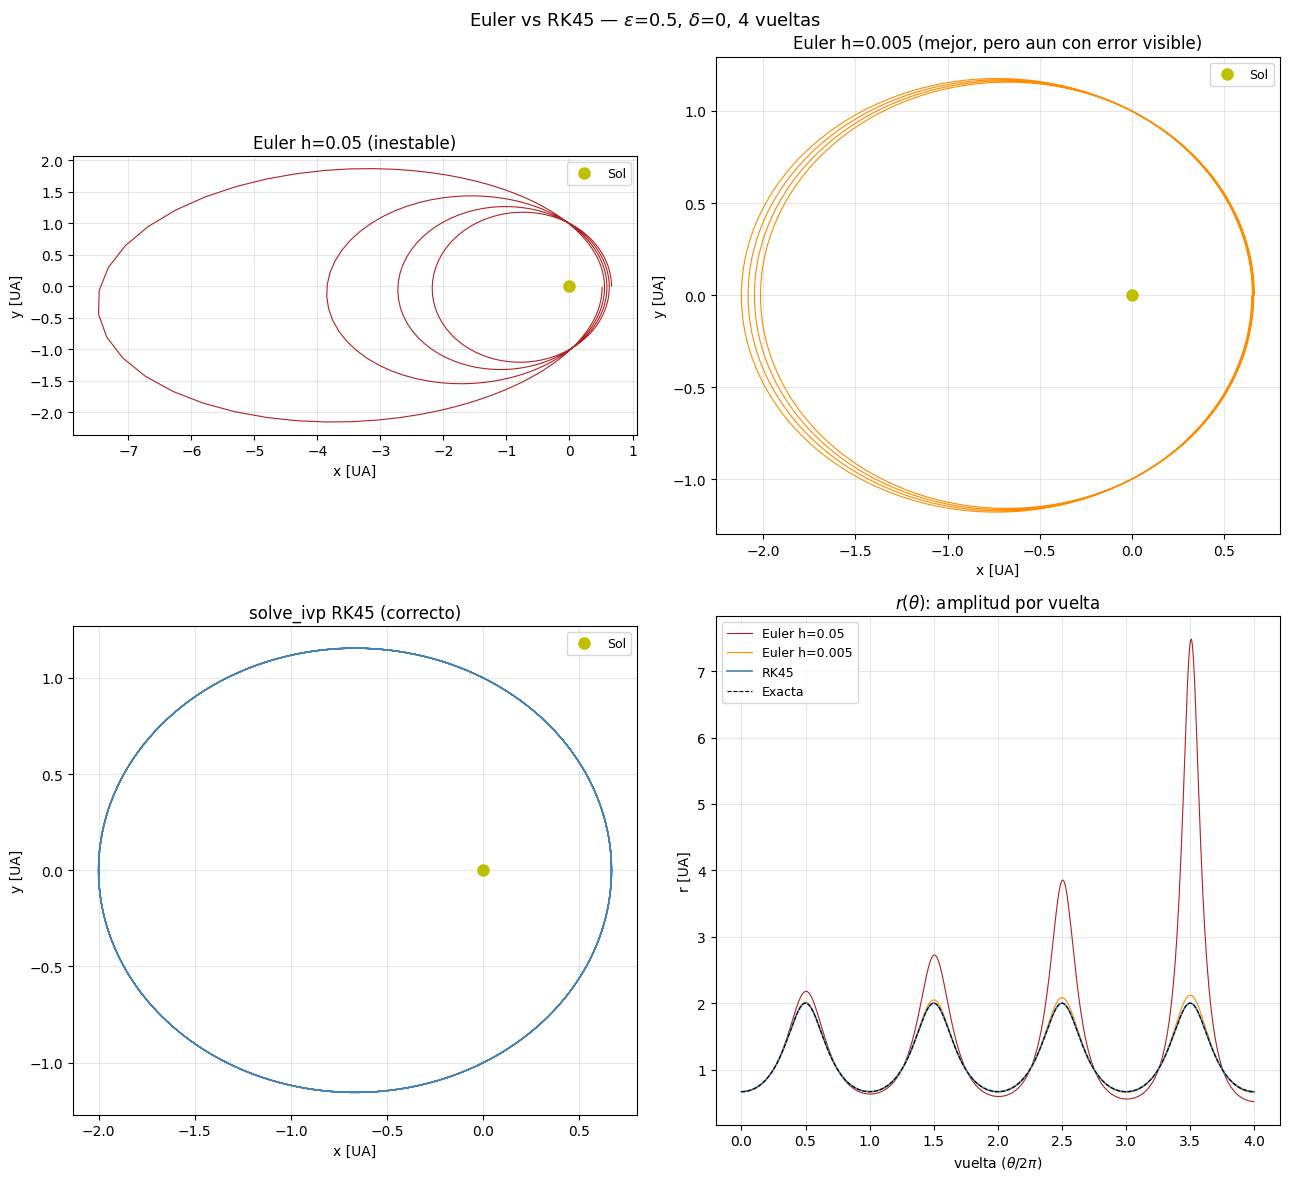

Error maximo |r_num - r_exacta| (4 vueltas):
  Euler h=0.05  : 5.4886
  Euler h=0.005 : 0.119858
  RK45          : 1.31e-08


In [14]:
# Comparacion Euler vs RK45: el mismo problema, tres niveles de paso
# alpha=1, eps=0.5, delta=0 (Kepler puro, solucion exacta conocida)
alpha_euler = 1.0
eps_euler   = 0.5
delta_euler = 0.0
theta0_e    = 0.0
theta_fin_e = 4 * 2 * np.pi       # 4 vueltas
estado_euler = [(1 + eps_euler) / alpha_euler, 0.0]

# --- Euler con h grande (h=0.05) ---
lt_e1, mu_e1, _ = euler_explicito(estado_euler, alpha_euler, delta_euler, theta0_e, theta_fin_e, 0.05)
xe1, ye1 = a_cartesiano(lt_e1, mu_e1)

# --- Euler con h chico (h=0.005) ---
lt_e2, mu_e2, _ = euler_explicito(estado_euler, alpha_euler, delta_euler, theta0_e, theta_fin_e, 0.005)
xe2, ye2 = a_cartesiano(lt_e2, mu_e2)

# --- solve_ivp (RK45) ---
nt_e  = 5000
lt_rk = np.linspace(theta0_e, theta_fin_e, nt_e)

sol_rk = solve_ivp(derivadas, [theta0_e, theta_fin_e], estado_euler,
                   t_eval=lt_rk, args=(alpha_euler, delta_euler),
                   rtol=1e-9, atol=1e-11)
xrk, yrk = a_cartesiano(sol_rk.t, sol_rk.y[0])

# --- Solucion exacta ---
thetas_ex = lt_rk
r_ex      = alpha_euler / (1 + eps_euler * np.cos(thetas_ex))

# --- Figura 2x2 ---
fig, axs = plt.subplots(2, 2, figsize=(13, 12))

ax = axs[0][0]
ax.set_aspect(1.0)
ax.set_title('Euler h=0.05 (inestable)')
ax.plot(xe1, ye1, 'firebrick', lw=0.8)
ax.plot(0, 0, 'yo', ms=8, label='Sol', zorder=5)
ax.legend(fontsize=9)
ax.set_xlabel('x [UA]')
ax.set_ylabel('y [UA]')
ax.grid(True, alpha=0.3)

ax = axs[0][1]
ax.set_aspect(1.0)
ax.set_title('Euler h=0.005 (mejor, pero aun con error visible)')
ax.plot(xe2, ye2, 'darkorange', lw=0.8)
ax.plot(0, 0, 'yo', ms=8, label='Sol', zorder=5)
ax.legend(fontsize=9)
ax.set_xlabel('x [UA]')
ax.set_ylabel('y [UA]')
ax.grid(True, alpha=0.3)

ax = axs[1][0]
ax.set_aspect(1.0)
ax.set_title('solve_ivp RK45 (correcto)')
ax.plot(xrk, yrk, 'steelblue', lw=1.0)
ax.plot(0, 0, 'yo', ms=8, label='Sol', zorder=5)
ax.legend(fontsize=9)
ax.set_xlabel('x [UA]')
ax.set_ylabel('y [UA]')
ax.grid(True, alpha=0.3)

ax = axs[1][1]
ax.set_title(r'$r(\theta)$: amplitud por vuelta')
r_e1 = 1.0 / np.array(mu_e1)
r_e2 = 1.0 / np.array(mu_e2)
r_rk = 1.0 / sol_rk.y[0]
ax.plot(np.array(lt_e1) / (2*np.pi), r_e1, 'firebrick',   lw=0.8, label='Euler h=0.05')
ax.plot(np.array(lt_e2) / (2*np.pi), r_e2, 'darkorange',  lw=0.8, label='Euler h=0.005')
ax.plot(sol_rk.t        / (2*np.pi), r_rk, 'steelblue',   lw=1.2, label='RK45')
ax.plot(thetas_ex       / (2*np.pi), r_ex, 'k--',         lw=0.8, label='Exacta')
ax.set_xlabel(r'vuelta ($\theta / 2\pi$)')
ax.set_ylabel('r [UA]')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle(r'Euler vs RK45 — $\varepsilon$=0.5, $\delta$=0, 4 vueltas', fontsize=13)
plt.tight_layout()
plt.savefig(r'graficos\figura_1_euler_vs_rk45.png', dpi=120, bbox_inches='tight')
plt.show()

# Error maximo contra la solucion exacta
r_ex_e1  = alpha_euler / (1 + eps_euler * np.cos(np.array(lt_e1)))
r_ex_e2  = alpha_euler / (1 + eps_euler * np.cos(np.array(lt_e2)))
r_ex_rk  = alpha_euler / (1 + eps_euler * np.cos(sol_rk.t))
err_e1   = np.max(np.abs(r_e1 - r_ex_e1))
err_e2   = np.max(np.abs(r_e2 - r_ex_e2))
err_rk   = np.max(np.abs(r_rk - r_ex_rk))
print('Error maximo |r_num - r_exacta| (4 vueltas):')
print('  Euler h=0.05  : ' + str(round(err_e1, 4)))
print('  Euler h=0.005 : ' + str(round(err_e2, 6)))
print('  RK45          : ' + str(round(err_rk, 10)))